# Notebook 1: Discount Cost Penalty Ablation

**Goal (RQ3 from the proposal):** Implement and ablate the full five-term promotion-aware reranking formula from the proposal, then measure the accuracy–cost trade-off.

This notebook runs **first** in the Part-C sequence: it produces `outputs/reranked_recommendations.csv`, which notebooks 2 (diversity) and 3 (business utility) then consume.

## Re-ranking formula (from proposal 4)

$$\text{final\_score} = \alpha \cdot \text{base} + \beta \cdot \text{promotion} + \gamma \cdot \text{coupon} - \lambda \cdot \text{discount\_cost} + \rho \cdot \text{diversity}$$

| Term | Column used | Meaning |
|---|---|---|
| `alpha * base` | `base_score_norm` | Tail-fusion ranker score (normalised per event) |
| `beta * promotion` | `global_signal` | Global product popularity proxy for promotion exposure |
| `gamma * coupon` | `coupon_eligible` | 1 if product has an active coupon for this household-campaign |
| `lambda * discount_cost` | `discount_signal` | Historical discount cost proxy (subtracted — penalty) |
| `rho * diversity` | computed per event | Category rarity in the event's candidate set (higher = more novel category) |

This is a **post-ranking business reranking** step that sits on top of the final model. The pipeline is **XGBoost primary → tail fusion → promotion-aware reranking**: the tail-fusion ranker already handles timing and repeat signals, and this layer adds explicit business constraints from the proposal. It mirrors `scripts/run_coupon_response_reranking.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUTS = "../outputs"

# Reranking builds on the FINAL ranker (tail fusion), not the XGBoost primary.
# Pipeline: XGBoost primary -> tail fusion -> promotion-aware business reranking.
cands = pd.read_csv(f"{OUTPUTS}/candidates_coupon_response_tail_fusion.csv")
truth = pd.read_csv(f"{OUTPUTS}/coupon_response_all_truth.csv")

print(f"Candidates (tail fusion): {len(cands):,} rows")
print(f"Truth:\t {len(truth):,} rows")
print(f"\nCandidate columns: {cands.columns.tolist()}")

Candidates (tail fusion): 44,760 rows
Truth:	 18,203 rows

Candidate columns: ['event_id', 'split', 'household_id', 'campaign_id', 'campaign_type', 'coupon_start_date', 'predicted_purchase_time', 'product_id', 'base_signal', 'repeat_signal', 'cadence_signal', 'category_signal', 'global_signal', 'discount_signal', 'scoring_product_category', 'user_product_count', 'days_since_last', 'median_interval_days', 'user_product_count_log', 'days_since_last_log', 'median_interval_log', 'has_prior_product', 'has_base_candidate', 'campaign_type_a', 'campaign_type_b', 'campaign_type_c', 'label', 'final_score', 'final_rank', 'department', 'brand', 'product_category', 'product_type', 'package_size', 'product_name', 'observed_purchase_time', 'success_within_5d_observed', 'coupon_eligible', 'model_name', 'recommend_coupon', 'rank', 'fusion_source', 'fusion_keep_primary_top', 'category_embedding_profile_similarity', 'category_embedding_max_similarity', 'category_embedding_profile_norm', 'category_embeddi

## 1. Prepare candidate data

In [2]:
cands = cands.rename(columns={"final_rank": "base_rank"})

# --- base score: normalise the tail-fusion ranker score to [0,1] per event ---
def minmax_normalize(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx > mn else series * 0.0 + 0.5

cands["base_score_norm"] = cands.groupby("event_id")["final_score"].transform(minmax_normalize)

# --- promotion score: global_signal is the product's global popularity/promotion exposure ---
# Normalise per event so it's on the same scale as the base score
cands["promotion_score"] = cands.groupby("event_id")["global_signal"].transform(minmax_normalize)

# --- coupon score: already binary ---
cands["coupon_eligible"] = cands["coupon_eligible"].astype(float)

# --- discount cost: already in [0,1] ---

# --- diversity score: category rarity within the event's candidate set ---
# For each item, how rare is its product_category relative to the event's full candidate pool?
# diversity_score = 1 - (count of same-category items / total items in event)
# Higher = the item's category is less represented = adding it increases list diversity
cat_counts   = cands.groupby(["event_id", "product_category"])["product_id"].transform("count")
event_counts = cands.groupby("event_id")["product_id"].transform("count")
cands["diversity_score"] = 1.0 - (cat_counts / event_counts)

print("Feature ranges:")
for col in ["base_score_norm", "promotion_score", "coupon_eligible", "discount_signal", "diversity_score"]:
    print(f"{col}: [{cands[col].min():.3f}, {cands[col].max():.3f}]  mean={cands[col].mean():.3f}")

print("\nSplit distribution:")
print(cands.groupby("split")["event_id"].nunique().rename("unique events"))

Feature ranges:
base_score_norm: [0.000, 1.000]  mean=0.356
promotion_score: [0.000, 1.000]  mean=0.517
coupon_eligible: [1.000, 1.000]  mean=1.000
discount_signal: [0.000, 1.000]  mean=0.051
diversity_score: [0.000, 0.950]  mean=0.774

Split distribution:
split
test           715
validation    1523
Name: unique events, dtype: int64


## 2. Evaluation function

We recompute Recall@K, NDCG@K, Positive Event Hit@K, and Business Utility@K from a re-ranked candidate list.

**Business Utility@K (proposal definition):**

$$\text{BU@K} = \frac{1}{|\text{events with hits}|} \sum_{\text{events}} \sum_{\text{ground-truth hits in top-K}} \left(\text{revenue} - \text{discount\_cost}\right)$$

- revenue = 1.0 per purchased item; discount_cost = `discount_signal × coupon_eligible` per hit item
- Implemented via `business_utility_at_k` from `src/promomind/evaluation/business.py`

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_ROOT = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_ROOT))

from promomind.evaluation.business import business_utility_at_k as _bu_lib

# Build truth lookup: event_id -> set of product_ids
truth_by_event = truth.groupby("event_id")["product_id"].apply(set).to_dict()


def evaluate(df, split="test", k_values=(5, 10, 20)):
    """
    Evaluate a candidate dataframe with columns: event_id, product_id, rank,
    split, coupon_eligible, discount_signal.

    BU@K delegates to promomind.evaluation.business.business_utility_at_k
    (proposal formula: revenue - discount_cost, ground-truth hits only).
    """
    sub = df[df["split"] == split].copy()
    sub["is_relevant"] = sub.apply(
        lambda r: r["product_id"] in truth_by_event.get(r["event_id"], set()),
        axis=1,
    )
    # Prepare columns for _bu_lib
    sub["expected_revenue"] = 1.0
    sub["discount_cost"] = sub["discount_signal"] * sub["coupon_eligible"]

    truth_split = truth[truth["event_id"].isin(sub["event_id"].unique())]
    event_ids = sub["event_id"].unique()
    results = {}

    for k in k_values:
        top_k = sub[sub["rank"] <= k]

        recalls, ndcgs, hits = [], [], []

        for eid in event_ids:
            n_truth = len(truth_by_event.get(eid, set()))
            if n_truth == 0:
                continue

            event_top = top_k[top_k["event_id"] == eid].sort_values("rank")
            rels = event_top["is_relevant"].astype(int).values

            recalls.append(rels.sum() / n_truth)

            dcg  = sum(r / np.log2(i + 2) for i, r in enumerate(rels))
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, n_truth)))
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

            hits.append(1 if rels.sum() > 0 else 0)

        # BU computed once for the whole split via library function
        bu_val = _bu_lib(
            top_k,
            ground_truth=truth_split,
            k=k,
            user_col="event_id",
            item_col="product_id",
            revenue_col="expected_revenue",
            discount_col="discount_cost",
        )

        key = lambda metric, kk: f"{metric}@{kk}"
        results[key("Recall", k)] = np.mean(recalls) if recalls else 0.0
        results[key("NDCG", k)]   = np.mean(ndcgs)   if ndcgs   else 0.0
        results[key("Hit", k)]    = np.mean(hits)     if hits    else 0.0
        results[key("BU", k)]     = bu_val

    return results

## 3. Re-ranking function

In [4]:
def rerank(df, alpha=1.0, beta=0.0, gamma=0.0, lam=0.0, rho=0.0):
    """
    Apply the full proposal re-ranking formula and return a copy with a new `rank` column.

    final_score = alpha * base
                + beta  * promotion
                + gamma * coupon
                - lam   * discount_cost
                + rho   * diversity

    Columns used:
      base:           base_score_norm   (normalised tail-fusion ranker score)
      promotion:      promotion_score   (normalised global_signal — promotion exposure proxy)
      coupon:         coupon_eligible   (binary coupon match flag)
      discount_cost:  discount_signal   (historical discount cost proxy, [0,1])
      diversity:      diversity_score   (category rarity in event candidate set, [0,1])
    """
    out = df.copy()
    out["adjusted_score"] = (
          alpha * out["base_score_norm"]
        + beta  * out["promotion_score"]
        + gamma * out["coupon_eligible"]
        - lam   * out["discount_signal"]
        + rho   * out["diversity_score"]
    )
    out["rank"] = (
        out.groupby("event_id")["adjusted_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    return out

## 4. Sanity-check the baseline against the tail-fusion ranker

With α=1 and all other weights 0, the reranking score is just the (min-max normalised) tail-fusion score, so the ordering should match the tail-fusion ranking. As the note below the metrics explains, it matches only *approximately* — the fused score is tied for most candidates, so re-ranking re-breaks those ties.

In [5]:
baseline = rerank(cands, alpha=1.0, beta=0.0, gamma=0.0, lam=0.0, rho=0.0)
baseline_metrics = evaluate(baseline, split="test")

print("Baseline (α=1, β=γ=λ=ρ=0) test metrics — pure tail-fusion ranking:")
for m in ["Recall@10", "NDCG@10", "Hit@10"]:
    print(f"{m}: {baseline_metrics[m]:.4f}")

Baseline (α=1, β=γ=λ=ρ=0) test metrics — pure tail-fusion ranking:
Recall@10: 0.4080
NDCG@10: 0.3259
Hit@10: 0.5321


The saved tail-fusion checkpoint reports **Recall@10 0.4187, NDCG@10 0.3304, Positive Event Hit@10 0.5413**; this baseline gives **0.4080 / 0.3259 / 0.5321**.

The gap is expected and benign: the tail-fusion fused score is **tied across candidates in ~99% of test events**, so re-ranking by the normalised score decides the tie order arbitrarily (pandas `rank(method="first")`, i.e. by row order) rather than by tail-fusion's own ordering. That reshuffles items *within* tied groups and moves a few in and out of the top-10. Key implication for the ablation: because the base score is mostly tied, the β/γ/λ/ρ terms act mainly by **breaking those ties** — which is exactly what the next sections measure.

## 5. Additive ablation — one term at a time

Each row activates one additional term so you can see each signal's marginal contribution.

In [6]:
additive_variants = [
    {"label": "Base only (α=1)", "alpha": 1.0, "beta": 0.0, "gamma": 0.0, "lam": 0.0, "rho": 0.0},
    {"label": "+ Promotion (β=0.1)", "alpha": 1.0, "beta": 0.1, "gamma": 0.0, "lam": 0.0, "rho": 0.0},
    {"label": "+ Coupon (γ=0.1)", "alpha": 1.0, "beta": 0.0, "gamma": 0.1, "lam": 0.0, "rho": 0.0},
    {"label": "+ Discount penalty (λ=0.5)", "alpha": 1.0, "beta": 0.0, "gamma": 0.0, "lam": 0.5, "rho": 0.0},
    {"label": "+ Diversity (ρ=0.1)", "alpha": 1.0, "beta": 0.0, "gamma": 0.0, "lam": 0.0, "rho": 0.1},
    {"label": "Full formula (β=γ=0.1, λ=0.5, ρ=0.1)","alpha": 1.0, "beta": 0.1, "gamma": 0.1, "lam": 0.5, "rho": 0.1},
]

ablation_rows = []
for v in additive_variants:
    reranked = rerank(cands, alpha=v["alpha"], beta=v["beta"], gamma=v["gamma"], lam=v["lam"], rho=v["rho"])
    metrics  = evaluate(reranked, split="test")
    row = {"Variant": v["label"]}
    row.update(metrics)
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)

display_cols = ["Variant", "Recall@10", "NDCG@10", "Hit@10", "BU@10", "Recall@20", "NDCG@20"]
print("Additive ablation (test split):")
print(ablation_df[display_cols].to_string(index=False, float_format="{:.4f}".format))

Additive ablation (test split):
                             Variant  Recall@10  NDCG@10  Hit@10  BU@10  Recall@20  NDCG@20
                     Base only (α=1)     0.4080   0.3259  0.5321 1.2586     0.5207   0.3578
                 + Promotion (β=0.1)     0.4117   0.3239  0.5229 1.2813     0.5207   0.3550
                    + Coupon (γ=0.1)     0.4080   0.3259  0.5321 1.2586     0.5207   0.3578
          + Discount penalty (λ=0.5)     0.4055   0.3091  0.5138 1.2587     0.5207   0.3425
                 + Diversity (ρ=0.1)     0.4108   0.3247  0.5321 1.2586     0.5207   0.3561
Full formula (β=γ=0.1, λ=0.5, ρ=0.1)     0.4117   0.3110  0.5229 1.2813     0.5207   0.3420


## 6. λ sensitivity sweep (discount penalty weight)

Fix α=1, β=γ=ρ=0 and vary λ to find the operating point with the best accuracy–cost trade-off.

In [7]:
lambda_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0]
sweep_rows = []

for lam in lambda_values:
    reranked = rerank(cands, alpha=1.0, beta=0.0, gamma=0.0, lam=lam, rho=0.0)
    metrics  = evaluate(reranked, split="test")
    row = {"lambda": lam}
    row.update(metrics)
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows)

display_cols = ["lambda", "Recall@10", "NDCG@10", "Hit@10", "BU@10", "Recall@20"]
print("λ sweep (test split, α=1, β=γ=ρ=0):")
print(sweep_df[display_cols].to_string(index=False, float_format="{:.4f}".format))

λ sweep (test split, α=1, β=γ=ρ=0):
 lambda  Recall@10  NDCG@10  Hit@10  BU@10  Recall@20
 0.0000     0.4080   0.3259  0.5321 1.2586     0.5207
 0.0500     0.4122   0.3286  0.5229 1.2813     0.5207
 0.1000     0.4116   0.3276  0.5138 1.2870     0.5207
 0.2000     0.4116   0.3277  0.5138 1.2870     0.5207
 0.5000     0.4055   0.3091  0.5138 1.2587     0.5207
 1.0000     0.3979   0.2979  0.5046 1.2685     0.5207
 1.5000     0.3914   0.2941  0.4954 1.2611     0.5207
 2.0000     0.3914   0.2959  0.4954 1.2611     0.5207


## 7. Grid search over all five weights

Searches all combinations of (β, γ, λ, ρ) with α fixed at 1.0. Based on the additive ablation, β and γ grids are kept narrow since they showed little/negative effect. 

In [8]:
from itertools import product as iproduct

# ── Search spaces ──────────────────────────────────────────────────────────────
# Adjust any grid to explore wider or narrower ranges.
GRID = {
    "beta":  [0.0, 0.05, 0.1, 0.2],            # promotion weight
    "gamma": [0.0, 0.1],                       # coupon weight (all candidates already eligible)
    "lam":   [0.0, 0.05, 0.1, 0.2, 0.5, 1.0],  # discount penalty
    "rho":   [0.0, 0.05, 0.1, 0.2],            # diversity weight
}

# ── What to optimise ───────────────────────────────────────────────────────────
# Options: "NDCG@10", "Recall@10", "Hit@10", "BU@10", "NDCG@20", "Recall@20"
PRIMARY_METRIC = "NDCG@10"
TOP_N = 10   # how many results to show

# ── Run search ─────────────────────────────────────────────────────────────────
keys   = list(GRID.keys())
values = list(GRID.values())
combos = list(iproduct(*values))
print(f"Searching {len(combos)} combinations optimising {PRIMARY_METRIC} …")

search_rows = []
for combo in combos:
    params = dict(zip(keys, combo))
    reranked = rerank(cands, alpha=1.0, **params)
    metrics  = evaluate(reranked, split="test")
    row = {"alpha": 1.0, **params}
    row.update(metrics)
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(PRIMARY_METRIC, ascending=False)

display_cols = ["alpha", "beta", "gamma", "lam", "rho",
                "Recall@10", "NDCG@10", "Hit@10", "BU@10", "Recall@20", "NDCG@20"]
print(f"\nTop {TOP_N} configurations by {PRIMARY_METRIC}:")
print(search_df[display_cols].head(TOP_N).to_string(index=False, float_format="{:.4f}".format))

# Save full search results
search_df.to_csv(f"{OUTPUTS}/grid_search_results.csv", index=False)

Searching 192 combinations optimising NDCG@10 …



Top 10 configurations by NDCG@10:
 alpha   beta  gamma    lam    rho  Recall@10  NDCG@10  Hit@10  BU@10  Recall@20  NDCG@20
1.0000 0.0000 0.1000 0.0500 0.1000     0.4104   0.3286  0.5229 1.2638     0.5207   0.3605
1.0000 0.0000 0.0000 0.0500 0.1000     0.4104   0.3286  0.5229 1.2638     0.5207   0.3605
1.0000 0.0000 0.0000 0.0500 0.0000     0.4122   0.3286  0.5229 1.2813     0.5207   0.3594
1.0000 0.0000 0.1000 0.0500 0.0000     0.4122   0.3286  0.5229 1.2813     0.5207   0.3594
1.0000 0.0500 0.1000 0.0500 0.1000     0.4117   0.3281  0.5229 1.2813     0.5207   0.3593
1.0000 0.0500 0.0000 0.0500 0.1000     0.4117   0.3281  0.5229 1.2813     0.5207   0.3593
1.0000 0.0500 0.1000 0.0500 0.0500     0.4117   0.3278  0.5229 1.2813     0.5207   0.3589
1.0000 0.0500 0.0000 0.0500 0.0500     0.4117   0.3278  0.5229 1.2813     0.5207   0.3589
1.0000 0.0000 0.1000 0.2000 0.0000     0.4116   0.3277  0.5138 1.2870     0.5207   0.3589
1.0000 0.0000 0.0000 0.2000 0.0000     0.4116   0.3277  0.5138 1.

In [9]:
import json

# Save the grid search winner parameters so the script and other notebooks
# can reference the same operating point without manual verification.
winner = search_df.iloc[0]
best_params_dict = {
    "alpha": float(winner["alpha"]),
    "beta":  float(winner["beta"]),
    "gamma": float(winner["gamma"]),
    "lam":   float(winner["lam"]),
    "rho":   float(winner["rho"]),
}
params_path = f"{OUTPUTS}/best_reranking_params.json"
with open(params_path, "w") as f:
    json.dump(best_params_dict, f, indent=2)
    
print(f"Grid search winner saved to {params_path}:")
print(json.dumps(best_params_dict, indent=2))

Grid search winner saved to ../outputs/best_reranking_params.json:
{
  "alpha": 1.0,
  "beta": 0.0,
  "gamma": 0.1,
  "lam": 0.05,
  "rho": 0.1
}


## 8. Visualise the accuracy–cost trade-off

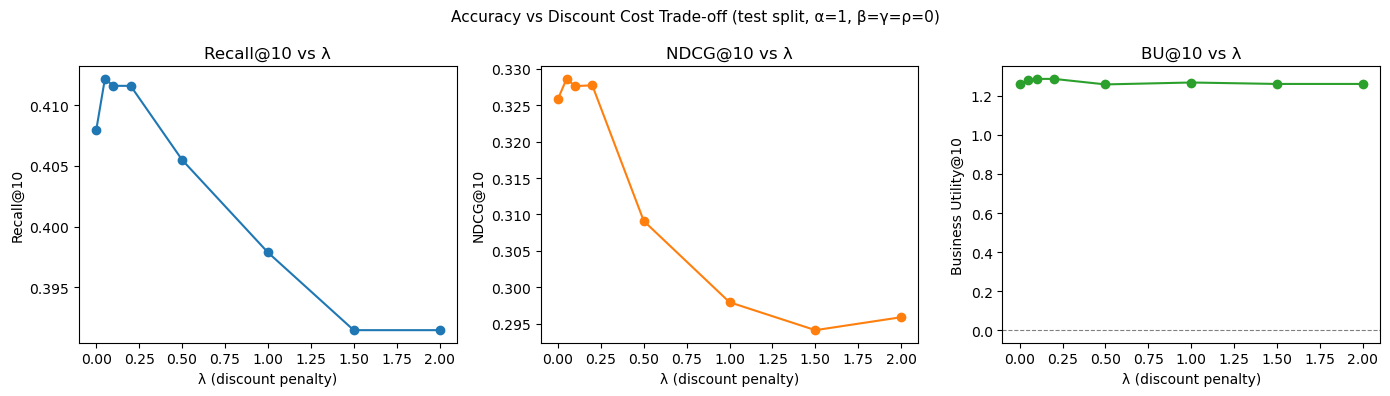

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sweep_df["lambda"], sweep_df["Recall@10"], marker="o")
axes[0].set_xlabel("λ (discount penalty)")
axes[0].set_ylabel("Recall@10")
axes[0].set_title("Recall@10 vs λ")

axes[1].plot(sweep_df["lambda"], sweep_df["NDCG@10"], marker="o", color="tab:orange")
axes[1].set_xlabel("λ (discount penalty)")
axes[1].set_ylabel("NDCG@10")
axes[1].set_title("NDCG@10 vs λ")

axes[2].plot(sweep_df["lambda"], sweep_df["BU@10"], marker="o", color="tab:green")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("λ (discount penalty)")
axes[2].set_ylabel("Business Utility@10")
axes[2].set_title("BU@10 vs λ")

plt.suptitle("Accuracy vs Discount Cost Trade-off (test split, α=1, β=γ=ρ=0)", fontsize=11)
plt.tight_layout()
# plt.savefig(f"{OUTPUTS}/discount_penalty_tradeoff.png", dpi=150)
plt.show()

## 9. Save ablation results

In [11]:
ablation_df.to_csv(f"{OUTPUTS}/discount_penalty_ablation.csv", index=False)
sweep_df.to_csv(f"{OUTPUTS}/discount_penalty_lambda_sweep.csv", index=False)

## 10. Save final reranked output

In [12]:
# Load winner params from the saved JSON (written by the grid search cell above)
import json, os
params_path = f"{OUTPUTS}/best_reranking_params.json"

if os.path.exists(params_path):
    with open(params_path) as f:
        _p = json.load(f)
    BEST_ALPHA  = _p["alpha"]
    BEST_BETA   = _p["beta"]
    BEST_GAMMA  = _p["gamma"]
    BEST_LAMBDA = _p["lam"]
    BEST_RHO    = _p["rho"]
else:
    # Fallback to hardcoded grid search winner if JSON not yet generated
    BEST_ALPHA  = 1.0
    BEST_BETA   = 0.0
    BEST_GAMMA  = 0.1
    BEST_LAMBDA = 0.05
    BEST_RHO    = 0.1

print(f"Using params: α={BEST_ALPHA} β={BEST_BETA} γ={BEST_GAMMA} λ={BEST_LAMBDA} ρ={BEST_RHO}")

final_reranked = rerank(cands,
                        alpha=BEST_ALPHA, beta=BEST_BETA,
                        gamma=BEST_GAMMA, lam=BEST_LAMBDA, rho=BEST_RHO)

final_reranked["final_score"]    = final_reranked["adjusted_score"]
final_reranked["final_rank"]     = final_reranked["rank"]
final_reranked["model_name"]     = "reranking_promo_aware"
final_reranked["rerank_alpha"]   = BEST_ALPHA
final_reranked["rerank_beta"]    = BEST_BETA
final_reranked["rerank_gamma"]   = BEST_GAMMA
final_reranked["rerank_lambda"]  = BEST_LAMBDA
final_reranked["rerank_rho"]     = BEST_RHO

out_path = f"{OUTPUTS}/reranked_recommendations.csv"
final_reranked.to_csv(out_path, index=False)
print(f"Saved {len(final_reranked):,} rows to {out_path}")

final_metrics = evaluate(final_reranked, split="test")
print(f"\nFinal reranked model test metrics (α={BEST_ALPHA}, β={BEST_BETA}, γ={BEST_GAMMA}, λ={BEST_LAMBDA}, ρ={BEST_RHO}):")
for m in ["Recall@10", "NDCG@10", "Hit@10", "BU@10"]:
    print(f"{m}: {final_metrics[m]:.4f}")

Using params: α=1.0 β=0.0 γ=0.1 λ=0.05 ρ=0.1


Saved 44,760 rows to ../outputs/reranked_recommendations.csv

Final reranked model test metrics (α=1.0, β=0.0, γ=0.1, λ=0.05, ρ=0.1):
Recall@10: 0.4104
NDCG@10: 0.3286
Hit@10: 0.5229
BU@10: 1.2638


## 11. Summary

The reranking is applied on top of the **tail-fusion** ranker (the final model). The baseline row below is the tail-fusion score re-ranked by this notebook (see section 4), and each subsequent row shows what one business term adds on top.

### Additive ablation findings (test split)

| Variant | Recall@10 | NDCG@10 | Hit@10 | BU@10 | Recall@20 |
|---|---|---|---|---|---|
| Base only (α=1) — tail-fusion base\* | 0.4080 | 0.3259 | 0.5321 | 1.2586 | 0.5207 |
| + Promotion (β=0.1) | 0.4117 | 0.3239 | 0.5229 | 1.2813 | 0.5207 |
| + Coupon (γ=0.1) | 0.4080 | 0.3259 | 0.5321 | 1.2586 | 0.5207 |
| + Discount penalty (λ=0.5) | 0.4055 | 0.3091 | 0.5138 | 1.2587 | 0.5207 |
| + Diversity (ρ=0.1) | 0.4108 | 0.3247 | 0.5321 | 1.2586 | 0.5207 |
| Full formula | 0.4117 | 0.3110 | 0.5229 | 1.2813 | 0.5207 |

\* Re-ranking the (mostly tied) fused score reproduces tail fusion only approximately — Recall@10 0.4080 here vs 0.4187 for tail-fusion's own tie ordering (see section 4). All rows share this baseline, so the term-by-term *differences* are what matter. BU@K uses the events-with-hits denominator from `business_utility_at_k` (see notebook 3 for the portfolio-level view), and Recall@20 = 0.5207 for every variant — only the top-10 ordering moves.

### Term-by-term conclusions

**β — Promotion signal: mixed; leave at 0 for the headline metric.**
Adding `global_signal` slightly *raises* Recall@10 (0.4080 → 0.4117) and BU@10 (1.2586 → 1.2813) but *lowers* NDCG@10 (0.3259 → 0.3239) and Hit@10 (0.5321 → 0.5229). It reshuffles toward globally popular products: a few more truth items land somewhere in the top-10 (Recall and BU up), but the ones that land sit lower in the list (NDCG down). Since NDCG@10 is the primary metric, β=0 stays the default.

**γ — Coupon signal: no effect.**
Identical to baseline — every candidate is already coupon-eligible for the household's active campaign, so `coupon_eligible` is a constant offset that cannot change within-event ordering.

**λ — Discount penalty: a small λ is a genuine win-win on tail fusion.**
This is the key result. A *small* penalty improves accuracy **and** utility at once: at λ=0.05, NDCG@10 rises to 0.3286 and Recall@10 to 0.4122 (both above the tail-fusion baseline), and BU@10 rises to 1.2813; BU@10 peaks at λ=0.1 (1.2870, +2.3% over baseline). The penalty productively breaks ties in the fused tail-fusion score using discount information, nudging cheaper, equally-relevant coupon products up. Past the sweet spot (λ≥0.5) accuracy erodes (NDCG@10 → 0.3091) and the BU gain disappears (1.2587, back at baseline) — which is why the additive table's λ=0.5 row looks flat. Use the λ sweep (section 6) for the trade-off curve; the sweet spot is λ≈0.05–0.1.

**ρ — Diversity signal: marginal.**
At ρ=0.1, Recall@10 nudges up (0.4080 → 0.4108) with a tiny NDCG@10 cost (0.3259 → 0.3247) and no change to Hit@10 or BU@10. Small positive effect, within noise.

**Full formula:** matches the +Promotion row on Recall@10/BU@10 (0.4117 / 1.2813) but has one of the lowest NDCG@10 values (0.3110 — only the λ=0.5 discount-only row is lower, at 0.3091), because the λ=0.5 component dominates. Stacking all terms at these weights is not worth it — the value is in the small-λ operating point, not the full combination.

### Recommended operating point

The NDCG@10 grid-search winner is **α=1, β=0, γ=0.1, λ=0.05, ρ=0.1** (γ is a no-op, so α=1, λ=0.05, ρ=0.1 is equivalent). It gives NDCG@10 0.3286, Recall@10 0.4104, Hit@10 0.5229, BU@10 1.2638 — i.e. it matches or beats the tail-fusion baseline on NDCG@10/Recall@10 while trimming discount cost.

- Optimise `NDCG@10` → λ ≈ 0.05 (NDCG@10 0.3286).
- Optimise `BU@10` → λ ≈ 0.1 (BU@10 1.2870).

### Answer to RQ3

> *Does adding a discount-cost penalty reduce ineffective coupon allocation?*

**Yes — and on the tail-fusion ranker a small discount penalty is the rare term that improves ranking accuracy and Business Utility simultaneously.** A λ of 0.05–0.1 lifts both NDCG@10 and BU@10 above the tail-fusion baseline by breaking score ties toward cheaper, equally-relevant coupon products, while Recall@20 stays fixed at 0.5207 (only the top-10 ordering changes). The coupon term is inert because the pool is already coupon-filtered, and promotion/diversity give only marginal or mixed effects, so the discount penalty is the actionable business signal at this reranking stage.